<a href="https://colab.research.google.com/github/AngelGarcia0905/IA/blob/main/AF7_Redes_Neuronales_Artificiales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS Y DIAGNÓSTICO
# -----------------------------------------
# Esta celda centraliza las dependencias de Deep Learning y diagnóstico de hardware.

import platform # Para identificar el sistema operativo.
import psutil   # Para estadísticas de memoria RAM y CPU.
import os       # Para interactuar con el entorno de Google Colab.
import numpy as np # Para manipulación de arreglos numéricos.
import matplotlib.pyplot as plt # Para visualización de imágenes y gráficas.
import tensorflow as tf # Librería principal de Deep Learning.
from tensorflow import keras # Interfaz de alto nivel para redes neuronales.
from tensorflow.keras import layers # Para definir las capas de la red.
from sklearn.metrics import confusion_matrix # Para evaluar el rendimiento.

def get_system_info():
    print(f"{'='*20} DIAGNÓSTICO INICIAL {'='*20}")
    print(f"Sistema: {platform.system()} {platform.release()}") # Info del SO.
    print(f"RAM Total: {round(psutil.virtual_memory().total / (1024**3), 2)} GB") # Memoria.
    # Verifica si hay una GPU disponible en Colab para acelerar el proceso.
    gpu = tf.config.list_physical_devices('GPU')
    print(f"Acelerador GPU: {'Disponible' if gpu else 'No detectado (Usando CPU)'}")

get_system_info() # Ejecuta la verificación del entorno.

==================== DIAGNÓSTICO INICIAL ====================
Sistema: Linux 6.6.113+
RAM Total: 12.67 GB
Acelerador GPU: Disponible


In [2]:
# 2. CARGA DEL CONJUNTO DE DATOS
# ------------------------------
# Se obtienen las imágenes de dígitos (0-9) para entrenamiento y prueba.

# Carga automática del dataset MNIST dividido en entrenamiento y prueba.
(train_data, train_labels), (test_data, test_labels) = keras.datasets.mnist.load_data()

print(f"Datos de entrenamiento: {train_data.shape}") # 60,000 imágenes de 28x28.
print(f"Datos de prueba: {test_data.shape}") # 10,000 imágenes de 28x28.
print(f"Categorías (Dígitos): {np.unique(train_labels)}") # Muestra etiquetas del 0 al 9.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Datos de entrenamiento: (60000, 28, 28)
Datos de prueba: (10000, 28, 28)
Categorías (Dígitos): [0 1 2 3 4 5 6 7 8 9]


In [3]:
# 3. PREPROCESAMIENTO DE DATOS
# ----------------------------
# Preparación de las imágenes para que la red neuronal pueda procesarlas.

# Normalización: Convertir píxeles (0-255) a un rango de 0 a 1 para facilitar el aprendizaje.
train_data = train_data.astype("float32") / 255
test_data = test_data.astype("float32") / 255

# Aplanado (Flattening): Convertir matrices de 28x28 a un vector unidimensional de 784 elementos.
# Esto es necesario para redes prealimentadas (Feedforward).
train_data_flat = train_data.reshape((60000, 28 * 28))
test_data_flat = test_data.reshape((10000, 28 * 28))

print("Preprocesamiento completado: Imágenes normalizadas y aplanadas.")

Preprocesamiento completado: Imágenes normalizadas y aplanadas.


In [4]:
# 4. SELECCIÓN Y ESTRUCTURA DEL MODELO
# ------------------------------------
# Definición de la arquitectura de la Red Neuronal Artificial.

# Definición de un modelo secuencial (capa tras capa).
model = keras.Sequential([
    layers.Dense(512, activation='relu', input_shape=(28 * 28,)), # Capa oculta 1 con 512 neuronas.
    layers.Dense(256, activation='relu'), # Capa oculta 2 con 256 neuronas.
    layers.Dense(10, activation='softmax') # Capa de salida con 10 neuronas (una por dígito).
])

# Configuración del entrenamiento.
model.compile(
    optimizer='adam', # Optimizador que ajusta los pesos eficientemente.
    loss='sparse_categorical_crossentropy', # Función de pérdida para clasificación múltiple.
    metrics=['accuracy'] # Métrica para evaluar la exactitud.
)

model.summary() # Muestra la arquitectura y el número de parámetros.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# 5. ENTRENAMIENTO DEL MODELO
# ---------------------------
# El modelo ajusta sus pesos internos usando la función fit.

print("Iniciando entrenamiento...")
# Se entrena por 5 épocas (ciclos completos sobre los datos).
history = model.fit(train_data_flat, train_labels, epochs=5, batch_size=128, validation_split=0.1)

print("\nEntrenamiento finalizado.")

Iniciando entrenamiento...
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9296 - loss: 0.2400 - val_accuracy: 0.9712 - val_loss: 0.1024
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9746 - loss: 0.0844 - val_accuracy: 0.9765 - val_loss: 0.0817
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9831 - loss: 0.0541 - val_accuracy: 0.9767 - val_loss: 0.0830
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9873 - loss: 0.0391 - val_accuracy: 0.9808 - val_loss: 0.0677
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9919 - loss: 0.0259 - val_accuracy: 0.9762 - val_loss: 0.0864

Entrenamiento finalizado.


In [6]:
# 6. PRUEBA DEL MODELO CON DATOS DE PRUEBA
# ----------------------------------------
# Uso de la función evaluate para verificar el rendimiento real.

# Evalúa el modelo con datos que nunca vio durante el entrenamiento.
test_loss, test_acc = model.evaluate(test_data_flat, test_labels, verbose=2)

print(f"\nExactitud en el conjunto de prueba (Accuracy): {test_acc * 100:.2f}%")

313/313 - 3s - 9ms/step - accuracy: 0.9765 - loss: 0.0767

Exactitud en el conjunto de prueba (Accuracy): 97.65%


In [7]:
# 6. PRUEBA DEL MODELO CON DATOS DE PRUEBA
# ----------------------------------------
# Uso de la función evaluate para verificar el rendimiento real.

# Evalúa el modelo con datos que nunca vio durante el entrenamiento.
test_loss, test_acc = model.evaluate(test_data_flat, test_labels, verbose=2)

print(f"\nExactitud en el conjunto de prueba (Accuracy): {test_acc * 100:.2f}%")

313/313 - 1s - 2ms/step - accuracy: 0.9765 - loss: 0.0767

Exactitud en el conjunto de prueba (Accuracy): 97.65%


In [10]:
# 7. PREDICCIONES AUTOMÁTICAS E INTERFAZ DE USUARIO
# --------------------------------------------------
# Esta celda genera automáticamente los primeros 5 resultados
# y luego crea una interfaz para elegir cualquier muestra del conjunto de prueba.

from tensorflow.keras.models import load_model # (Opcional) Si cargas el modelo.
from ipywidgets import interact, IntSlider # Librería para widgets interactivos en Colab.
import numpy as np # Para manipulación de arreglos.
import matplotlib.pyplot as plt # Para graficar.

# --- PARTE 1: IMPRESIÓN AUTOMÁTICA DE 5 PREDICCIONES ---
# (Simula la salida que mostraste en tu captura de pantalla)

# Paso 1: Generar predicciones para todo el conjunto de prueba (10,000 muestras)
predicciones_prob = model.predict(test_data_flat, verbose=0)
# Paso 2: Convertir probabilidades de Softmax al número entero correspondiente (argmax)
predicciones = np.argmax(predicciones_prob, axis=1)

print(f"{'='*25} RESULTADOS AUTOMÁTICOS (TOP 5) {'='*25}\n")

# Paso 3: Bucle para imprimir formateado los primeros 5 resultados
for i in range(5):
    # Asignar valores real, predicho y resultado (True/False -> Correcto/Error)
    valor_real = test_labels[i]
    prediccion_modelo = predicciones[i]
    resultado = "CORRECTO" if valor_real == prediccion_modelo else "ERROR"

    # Imprimir con el mismo formato que en la imagen de referencia
    print(f"Muestra {i+1}:")
    print(f" -> Valor Real: {valor_real}")
    print(f" -> Predicción: {prediccion_modelo}")
    print(f" -> Resultado: {resultado}\n")

# --- PARTE 2: INTERFAZ VISUAL INTERACTIVA (ELEGIR MUESTRA) ---
# Esta sección crea un deslizador para ver cualquier imagen del dataset.

print(f"\n{'='*25} INTERFAZ VISUAL: ELIGE UNA MUESTRA {'='*25}\n")

# Paso 4: Definir la función que se actualizará al mover el deslizador
def visualizar_prediccion_interactiva(indice):
    """
    Función que dibuja la imagen y muestra la predicción para un índice dado.
    """
    # Limpiar cualquier figura anterior para que no se superpongan
    plt.close()

    # Obtener el valor real y la predicción para el índice seleccionado
    valor_real_muestra = test_labels[indice]
    prediccion_muestra = predicciones[indice]

    # Crear la figura visual
    plt.figure(figsize=(6,6), dpi=100) # Tamaño y resolución de la figura.

    # Dibujar la imagen de la muestra (re-aplanada a 28x28 para visualizar)
    plt.imshow(test_data[indice], cmap='gray')

    # Configurar el título dinámico con la información real vs predicha
    plt.title(f"Visual - Muestra #{indice} | Real: {valor_real_muestra} | Predicho: {prediccion_muestra}")

    # Eliminar los ejes (X/Y) para que la imagen sea más limpia
    plt.axis('off')

    # Desplegar la imagen final
    plt.show()

# Paso 5: Implementar el widget interactivo (interact)
# Crea un deslizador entero (IntSlider) para elegir del índice 0 al 9999 del dataset.
interact(visualizar_prediccion_interactiva,
         indice=IntSlider(min=0, max=len(test_data)-1, step=1, value=4, # value=4 inicia en el ejemplo visual que mostraste.
                          description='Elegir Muestra:', # Texto del deslizador.
                          continuous_update=True)); # Actualiza mientras arrastras.


========================= RESULTADOS AUTOMÁTICOS (TOP 5) =========================

Muestra 1:
 -> Valor Real: 7
 -> Predicción: 7
 -> Resultado: CORRECTO

Muestra 2:
 -> Valor Real: 2
 -> Predicción: 2
 -> Resultado: CORRECTO

Muestra 3:
 -> Valor Real: 1
 -> Predicción: 1
 -> Resultado: CORRECTO

Muestra 4:
 -> Valor Real: 0
 -> Predicción: 0
 -> Resultado: CORRECTO

Muestra 5:
 -> Valor Real: 4
 -> Predicción: 4
 -> Resultado: CORRECTO


========================= INTERFAZ VISUAL: ELIGE UNA MUESTRA =========================



interactive(children=(IntSlider(value=4, description='Elegir Muestra:', max=9999), Output()), _dom_classes=('w…

In [12]:
# 8. INTERFAZ DE ANÁLISIS DE FALLOS
# ----------------------------------
# Esta celda busca automáticamente todas las muestras donde el modelo se equivocó
# y permite navegar por ellas para entender por qué falló la Red Neuronal.

import numpy as np # Para operaciones lógicas con arreglos.
import matplotlib.pyplot as plt # Para graficar las imágenes de los fallos.
from ipywidgets import interact, IntSlider # Para la barra de navegación interactiva.

# Paso 1: Obtener las predicciones finales del modelo (clase con mayor probabilidad).
predicciones_finales = np.argmax(model.predict(test_data_flat, verbose=0), axis=1)

# Paso 2: Crear una lista con los índices donde la predicción NO coincide con el valor real.
indices_errores = np.where(predicciones_finales != test_labels)[0]

print(f"{'='*25} REPORTE DE ERRORES {'='*25}")
print(f"Total de muestras de prueba: {len(test_data)}")
print(f"Total de errores encontrados: {len(indices_errores)}")
print(f"Tasa de error: { (len(indices_errores)/len(test_data))*100 :.2f}%")
print(f"{'='*60}\n")

# Paso 3: Definir la función para visualizar solo los fallos.
def visualizar_fallos(indice_error):
    """
    Función que muestra la imagen del error basado en la lista de fallos.
    """
    plt.close() # Limpiar memoria de gráficos anteriores.

    # Obtener el índice real del dataset basándonos en la lista de errores.
    idx_real = indices_errores[indice_error]

    # Extraer los datos específicos de esa muestra fallida.
    imagen_fallo = test_data[idx_real]
    real = test_labels[idx_real]
    predicho = predicciones_finales[idx_real]

    # Crear la interfaz visual del error.
    plt.figure(figsize=(6,6), dpi=100)
    plt.imshow(imagen_fallo, cmap='gray') # Mostrar el dígito que confundió a la red.

    # Título que resalta el error en rojo para mejor visibilidad.
    plt.title(f"FALLO #{indice_error+1} (Muestra #{idx_real})\nREAL: {real} | PREDICCIÓN: {predicho}",
              color='red', fontsize=14, fontweight='bold')

    plt.axis('off') # Quitar ejes de coordenadas.
    plt.show() # Desplegar la imagen del error.

# Paso 4: Crear el control interactivo.
# El máximo del deslizador es el total de errores encontrados (menos 1).
if len(indices_errores) > 0:
    interact(visualizar_fallos,
             indice_error=IntSlider(min=0,
                                    max=len(indices_errores)-1,
                                    step=1,
                                    value=0,
                                    description='Ver Error:',
                                    style={'description_width': 'initial'},
                                    layout={'width': '500px'}))
else:
    print("¡Increíble! El modelo no cometió ningún error en este conjunto.")

# Nota para el alumno: Al mover el deslizador, verás que la red suele fallar en números
# que están muy mal escritos o que se parecen mucho a otros (como el 4 y el 9, o el 7 y el 2).

========================= REPORTE DE ERRORES =========================
Total de muestras de prueba: 10000
Total de errores encontrados: 235
Tasa de error: 2.35%



interactive(children=(IntSlider(value=0, description='Ver Error:', layout=Layout(width='500px'), max=234, styl…


==================== RESULTADO EN TIEMPO REAL ====================
Predicción del Modelo: 3
Nivel de Confianza: 96.70%


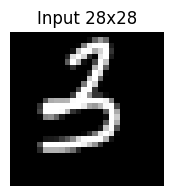

In [15]:
# 9. DIBUJO CONTINUO Y PREDICCIÓN CON MOUSEPAD
# --------------------------------------------
# Esta celda permite dibujar números y predecir múltiples veces
# sin necesidad de reiniciar o refrescar la página.

from IPython.display import HTML, display # Para renderizar la interfaz visual.
from google.colab import output           # Para conectar JavaScript con Python.
from base64 import b64decode              # Para decodificar la imagen del dibujo.
import cv2                                # Para procesamiento de imagen.
import numpy as np                        # Para manejo de arreglos numéricos.
import matplotlib.pyplot as plt           # Para mostrar la vista previa de la red.

# Definición de la interfaz visual con HTML y CSS
canvas_html = """
<div id="wrapper" style="border: 2px solid #555; padding: 20px; display: inline-block; background: #1e1e1e; border-radius: 15px; text-align: center; box-shadow: 0 4px 15px rgba(0,0,0,0.5);">
    <h3 style="color: #00d4ff; margin-top: 0; font-family: sans-serif;">Panel de Dibujo Interactiva</h3>
    <canvas id="canvas" width="280" height="280" style="border: 4px solid #333; background: black; cursor: crosshair; border-radius: 8px;"></canvas>
    <div style="margin-top: 15px;">
        <button id="predict" style="padding: 12px 25px; background: #28a745; color: white; border: none; border-radius: 5px; font-weight: bold; cursor: pointer; transition: 0.3s;">PREDECIR</button>
        <button id="clear" style="padding: 12px 25px; background: #dc3545; color: white; border: none; border-radius: 5px; font-weight: bold; cursor: pointer; margin-left: 10px;">BORRAR</button>
    </div>
    <div id="resultado_area" style="margin-top: 15px; color: #ffcc00; font-family: 'Courier New', monospace; font-size: 1.1em;">
        Dibuja un dígito (0-9) en el centro
    </div>
</div>

<script>
    var canvas = document.getElementById('canvas');
    var ctx = canvas.width && canvas.getContext('2d');
    var drawing = false;

    // Configuración del trazo para que parezca escritura humana
    ctx.strokeStyle = "white";
    ctx.lineWidth = 18;
    ctx.lineCap = "round";
    ctx.lineJoin = "round";

    // Lógica de dibujo con el mouse
    canvas.onmousedown = (e) => { drawing = true; ctx.beginPath(); ctx.moveTo(e.offsetX, e.offsetY); };
    canvas.onmousemove = (e) => { if (drawing) { ctx.lineTo(e.offsetX, e.offsetY); ctx.stroke(); } };
    window.onmouseup = () => { drawing = false; };

    // Función para limpiar el lienzo
    document.getElementById('clear').onclick = () => {
        ctx.clearRect(0, 0, canvas.width, canvas.height);
        document.getElementById('resultado_area').innerText = "Lienzo listo para otro número";
    };

    // Envía los datos a Python sin cerrar la celda
    document.getElementById('predict').onclick = () => {
        var dataURL = canvas.toDataURL('image/png');
        google.colab.kernel.invokeFunction('notebook.ProcesarDibujo', [dataURL], {});
    };
</script>
"""

# Función que recibe la imagen desde el navegador
def procesar_dibujo_usuario(data_url):
    # Paso 1: Decodificar el Base64 enviado por JavaScript
    header, encoded = data_url.split(",", 1)
    binary = b64decode(encoded)

    # Paso 2: Convertir a imagen de OpenCV (escala de grises)
    arr = np.frombuffer(binary, np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

    # Paso 3: Redimensionar a 28x28 (formato MNIST) y normalizar (0 a 1)
    img_res = cv2.resize(img, (28, 28), interpolation=cv2.INTER_AREA)
    img_flat = img_res.reshape(1, 28 * 28).astype('float32') / 255

    # Paso 4: Realizar la predicción con la red neuronal entrenada
    probabilidades = model.predict(img_flat, verbose=0)
    clase_predicha = np.argmax(probabilidades)
    certeza = np.max(probabilidades) * 100

    # Paso 5: Refrescar la interfaz y mostrar resultados
    output.clear(wait=True) # Limpia la consola de Python pero mantiene el HTML
    display(HTML(canvas_html))
    print(f"\n{'='*20} RESULTADO EN TIEMPO REAL {'='*20}")
    print(f"Predicción del Modelo: {clase_predicha}")
    print(f"Nivel de Confianza: {certeza:.2f}%")

    # Mostrar visualmente lo que procesó la red
    plt.figure(figsize=(2,2))
    plt.imshow(img_res, cmap='gray')
    plt.title(f"Input 28x28")
    plt.axis('off')
    plt.show()

# Registrar la conexión entre JS y Python
output.register_callback('notebook.ProcesarDibujo', procesar_dibujo_usuario)

# Mostrar la interfaz por primera vez
display(HTML(canvas_html))